TASK NO : 1

In [3]:
graph = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": [],
    "D": [],
    "E": []
}
def bfs(graph, start):
    queue = [start]
    visited = []

    print("BFS Traversal:")

    while queue:
        node = queue.pop(0)

        if node not in visited:
            print(node, end=" ")
            visited.append(node)
            queue.extend(graph[node])

# Run BFS
bfs(graph, "A")
def dfs(graph, node, visited):
    if node not in visited:
        print(node, end=" ")
        visited.append(node)

        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

print("\nDFS Traversal:")

# Run DFS
dfs(graph, "A", [])

BFS Traversal:
A B C D E 
DFS Traversal:
A B D E C 

TASK : 2


Processing Size: 1000

Processing Size: 5000

Processing Size: 10000

Processing Size: 20000

Processing Size: 50000

Results:
     Size  BFS Time  DFS Time
0   1000  0.000156  0.000120
1   5000  0.000894  0.000736
2  10000  0.002048  0.001709
3  20000  0.006121  0.004523
4  50000  0.011422  0.010724


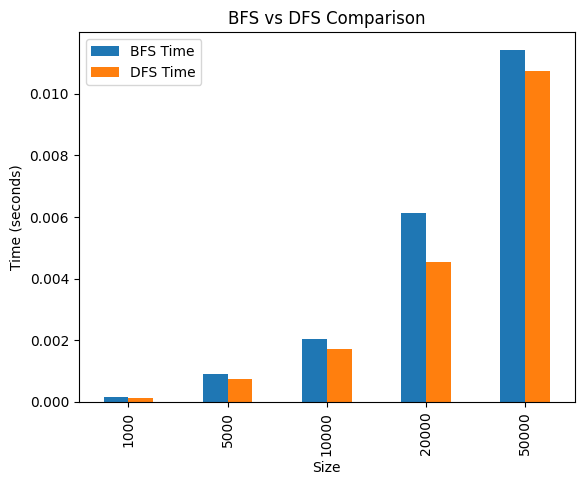

In [2]:
# STEP 1: Import libraries
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

def bfs(graph, start, goal):
    queue = deque([start])
    visited = set()

    while queue:
        node = queue.popleft()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])

def dfs(graph, start, goal):
    stack = [start]
    visited = set()

    while stack:
        node = stack.pop()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])


sizes = [1000, 5000, 10000, 20000, 50000]

results = []

for size in sizes:
    print("\nProcessing Size:", size)

    data = random.sample(range(size * 10), size)

    graph = {}
    for i in range(len(data) - 1):
        graph[data[i]] = [data[i + 1]]
    graph[data[-1]] = []

    start = data[0]
    goal = data[-min(220, len(data)-1)]

    t1 = time.time()
    bfs(graph, start, goal)
    t2 = time.time()

    t3 = time.time()
    dfs(graph, start, goal)
    t4 = time.time()

    results.append([size, t2 - t1, t4 - t3])

df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
print("\nResults:\n", df)

df.plot(x="Size", y=["BFS Time", "DFS Time"], kind="bar")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Comparison")
plt.show()

TASK : 3

In [1]:
# STEP 1: Import deque
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(graph, start, goal):
    queue = [[start]]
    visited = []

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.append(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

path = bfs_shortest_path(graph, "Islamabad", "Karachi")

print("Shortest Path:")
print(" → ".join(path))

Shortest Path:
Islamabad → Rawalpindi → Quetta → Karachi
